# CNN Model Creation and Training.

In [1]:
# imports 
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import pickle as pk
import matplotlib.pyplot as plt

In [2]:
TRAIN_TEST_PATH = "../datasets/processed/train_test"


In [3]:
# load X_train,X_test,Y_train,Y_test.

In [4]:
X_train = np.load(os.path.join(TRAIN_TEST_PATH,"X_train.npy"))
X_test = np.load(os.path.join(TRAIN_TEST_PATH,"X_test.npy"))
Y_train = np.load(os.path.join(TRAIN_TEST_PATH,"Y_train.npy"))
Y_test = np.load(os.path.join(TRAIN_TEST_PATH,"Y_test.npy"))

In [5]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(672, 1, 128, 216)
(168, 1, 128, 216)
(672,)
(168,)


In [6]:
X_train = X_train.transpose(0, 2, 3, 1)
X_test = X_test.transpose(0, 2, 3, 1)

In [7]:
# X_train = (X_train + 80) / 80
# X_test = (X_test + 80) / 80
# Normalization if needed.

In [8]:
print(np.unique(Y_train,return_counts=True))
print(np.unique(Y_test,return_counts=True))

(array([0, 1]), array([352, 320]))
(array([0, 1]), array([88, 80]))


In [9]:
print(X_train.max())
print(X_train.min())

0.0
-80.0


In [10]:
def create_cnn_model(input_shape=(128,216,1)):
    model = models.Sequential()

    model.add(layers.Conv2D(32,(3,3),padding='same',input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64,(3,3),padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(128,(3,3),padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2,2)))


    # model.add(layers.Flatten())
    model.add(layers.GlobalAveragePooling2D())

    model.add(layers.Dense(64))
    model.add(layers.ReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(1,activation='sigmoid'))

    return model


In [11]:
threat_detector = create_cnn_model()

c:\Users\vssuj\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [13]:
threat_detector.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
threat_detector.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 216, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 216, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 216, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 108, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,889 (398.00 KB)

 Trainable params: 101,441 (396.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
history = threat_detector.fit(
    X_train,
    Y_train,
    validation_data=(X_test,Y_test),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose = 1
)

Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 340ms/step - accuracy: 0.6250 - loss: 0.6566 - val_accuracy: 0.5238 - val_loss: 3.8791
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 346ms/step - accuracy: 0.6488 - loss: 0.6374 - val_accuracy: 0.4762 - val_loss: 0.7088
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 366ms/step - accuracy: 0.6682 - loss: 0.6154 - val_accuracy: 0.5298 - val_loss: 0.9452
Epoch 4/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 335ms/step - accuracy: 0.6711 - loss: 0.5855 - val_accuracy: 0.5179 - val_loss: 0.7277
Epoch 5/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 327ms/step - accuracy: 0.6964 - loss: 0.5821 - val_accuracy: 0.5952 - val_loss: 0.7267
Epoch 6/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 326ms/step - accuracy: 0.7128 - loss: 0.5736 - val_accuracy: 0.5595 - val_loss: 0.7467
Epoch 7/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 324ms/step - accuracy: 0.7440 - loss: 0.5348 - val_accuracy: 0.6667 - val_loss: 0.6235
Epoch 8/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 324ms/step - accuracy: 0.7842 - loss: 0.5025 - val_accu

In [16]:
best_epoch = np.argmax(history.history['val_accuracy']) + 1

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:",
      max(history.history['val_accuracy']))

Best Epoch: 17
Best Validation Accuracy: 0.8214285969734192


In [17]:
loss,acc = threat_detector.evaluate(X_test,Y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.8214 - loss: 0.4232 


In [18]:
print("Loss :",loss)
print("Accuracy :",acc)

# Accuracy : .875 and loss 0.31602 
# with out Normalization.
# and with normalilzation 
# Accuracy : .6858
# Loss = 0.547
# So no normalization

Loss : 0.42315182089805603
Accuracy : 0.8214285969734192


In [19]:
threat_detector.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 216, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 216, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 216, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 108, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,773 (1.16 MB)

 Trainable params: 101,441 (396.25 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 202,884 (792.52 KB)

In [20]:
Y_pred_prob = threat_detector.predict(X_test)

Y_pred = (Y_pred_prob > 0.5).astype(int)


print(Y_pred[:10])

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
[[0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]]


In [21]:
Y_pred = Y_pred.flatten()
Y_test = Y_test.flatten()

In [22]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("Confusion Matrix")
print(confusion_matrix(Y_test, Y_pred))

print("\nClassification Report")
print(classification_report(Y_test, Y_pred))

print("\nPrecision :", precision_score(Y_test, Y_pred))
print("Recall    :", recall_score(Y_test, Y_pred))
print("F1 Score  :", f1_score(Y_test, Y_pred))

Confusion Matrix
[[73 15]
 [15 65]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        88
           1       0.81      0.81      0.81        80

    accuracy                           0.82       168
   macro avg       0.82      0.82      0.82       168
weighted avg       0.82      0.82      0.82       168


Precision : 0.8125
Recall    : 0.8125
F1 Score  : 0.8125


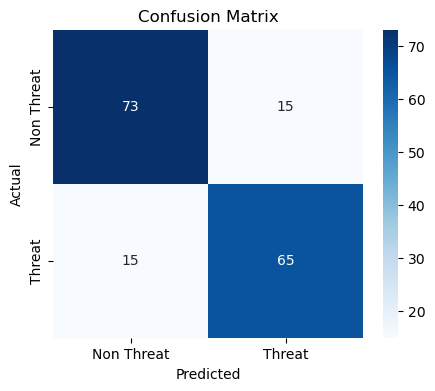

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non Threat','Threat'],
    yticklabels=['Non Threat','Threat']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

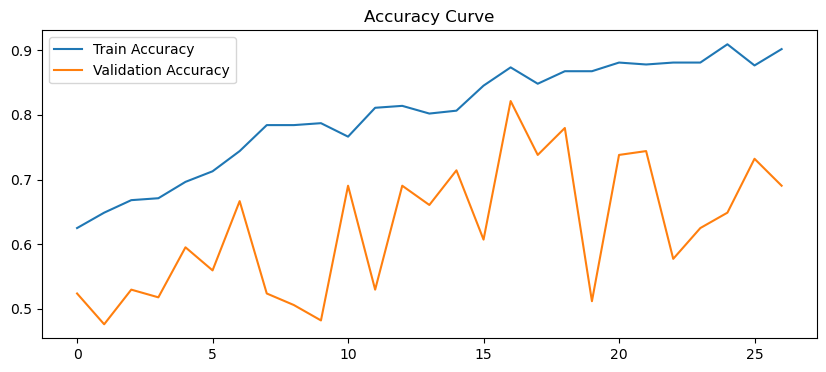

In [24]:
plt.figure(figsize=(10,4))

plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

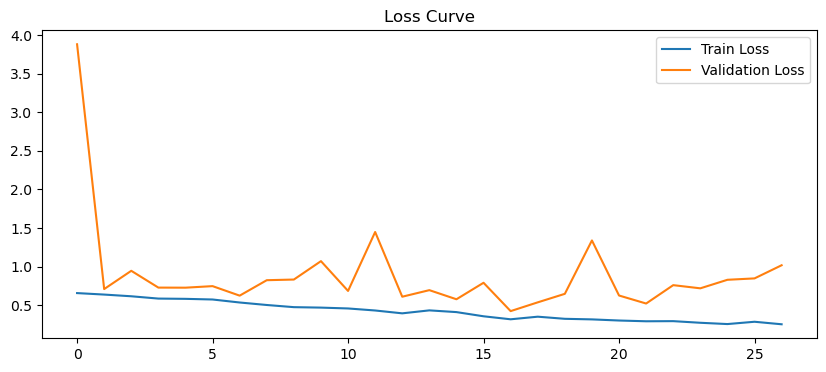

In [25]:
plt.figure(figsize=(10,4))

plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [26]:
threat_detector.save("../models/threat_detector.keras")
print("Model Saved Succesfully!!!")

Model Saved Succesfully!!!


In [27]:
with open("../models/training_history.pkl","wb") as f:
    pk.dump(history.history,f)